In [13]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sim_wrapper.sim import Sim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [14]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 9e9 * 2 * np.pi)
sim.add_param('w_J', 3e9 * 2 * np.pi)
sim.add_param('amp_in', 0.01) # signal amplitude
sim.add_param('kappa', 0.5e9 * 2 * np.pi)  # mode decay rate
sim.add_param('phase_in', 0)
sim.add_paramsweep('phi_DC', 0, 4*np.pi, 200)
sim.add_param('epsilon', 0)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_paramsweep('w_in', 8e9*2*np.pi, 10e9*2*np.pi, 100, is_excitation=True) # signal frequency

sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)') # does nothing for now
sim.add_EOM('x2', '-kappa*x2 - w_0**2*x1 - w_J**2*sin(x1+phi_DC) + 2*kappa*(-amp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 + amp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 400, d_factor=1)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


(3000000000.0, 30000000000.0)

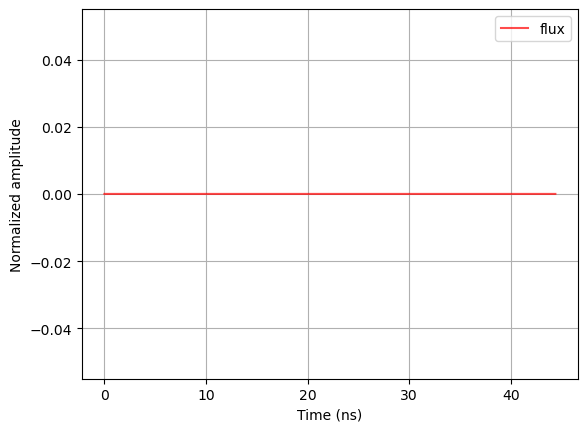

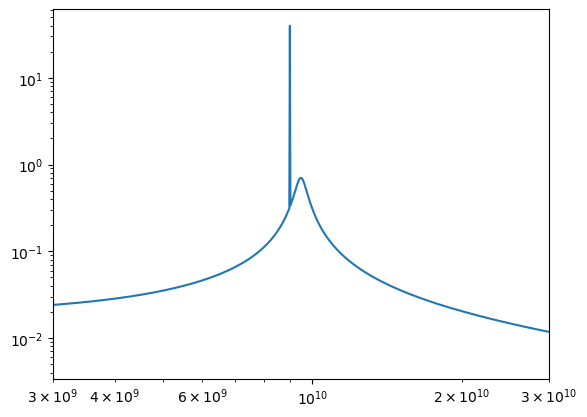

In [15]:
x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())
plt.xlim([3e9, 30e9])



In [16]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:03<00:00, 2158.09it/s]


 
...finished GPU solve!


Text(0, 0.5, 'freq (GHz)')

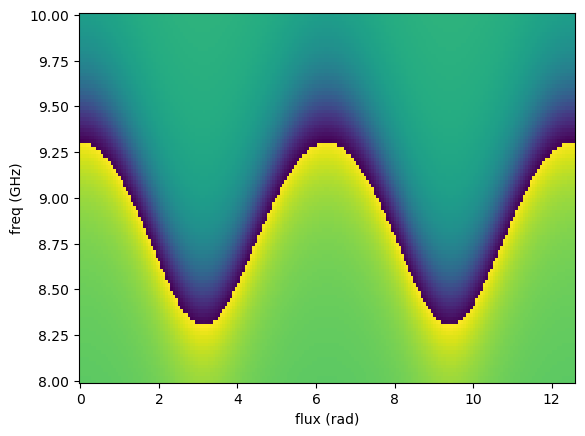

In [17]:
amp_max = np.max(np.sqrt(I**2 + Q**2))
amp_min = np.min(np.sqrt(I**2 + Q**2))
phase = np.angle(1j*Q+I)

plt.pcolor(sim.paramsweep_dict['phi_DC'],sim.paramsweep_dict['w_in']/(1e9*2*np.pi),  phase[3,:,:,-1].transpose())
plt.xlabel('flux (rad)')
plt.ylabel('freq (GHz)')

Now we introduce a time varying external flux, picking 1.5 as flux bias

In [6]:
sim = Sim(use_complex=False)

sim.add_param('w_0', 9e9 * 2 * np.pi)
sim.add_param('w_J', 3e9 * 2 * np.pi)
sim.add_paramsweep('logamp_in', -5,0, 30) # signal amplitude
sim.add_param('kappa', 0.5e9 * 2 * np.pi)  # mode decay rate
sim.add_paramsweep('phase_in', 0, 2*np.pi, 31)
sim.add_param('phi_DC', 1.5)
sim.add_param('epsilon', 0.1)
sim.add_param('w_phi', 1e9 * 2 * np.pi)
sim.add_param('w_in', 9e9*2*np.pi) # signal frequency
sim.add_param('w_d', 8e9*2*np.pi, is_excitation=True)

sim.add_EOM('x1', 'x2')
sim.add_EOM('phi_flux', 'epsilon*w_phi*cos(w_phi*t)', IC=sim.param_dict['phi_DC'])
sim.add_EOM('x2', '-kappa*x2 - w_0**2*x1 - w_J**2*sin(x1+phi_flux) + 2*kappa*(-10**logamp_in*w_in*cos(w_in*t + phase_in))')
sim.add_EOM('x3','x2 + 10**logamp_in*w_in*cos(w_in*t + phase_in)')

sim.set_solve_type('decimate')

sim.specify_time(20, 400, d_factor=1)

sim.validate()

Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


(3000000000.0, 30000000000.0)

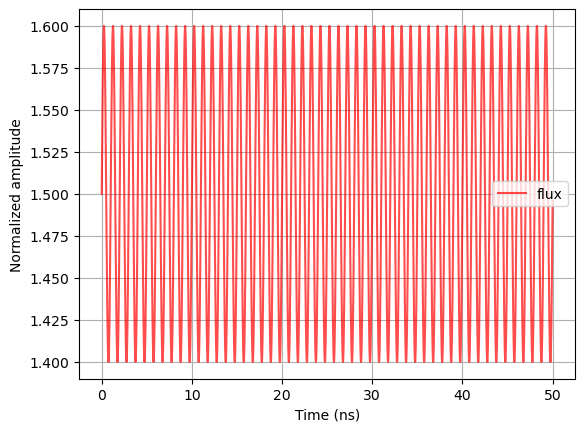

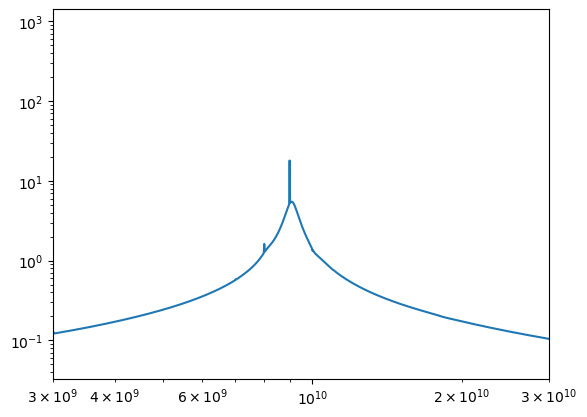

In [7]:
x, t = sim.quick_trace()

plt.figure(1)
plt.plot(t*1e9, x[1,:],color=(1,0,0,0.7),label='flux')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()

plt.figure(2)
fftx = np.fft.fft(x[3, :])
freqs = np.linspace(0, len(t)/t[-1], len(t))
plt.loglog(freqs, np.abs(fftx).transpose())
plt.xlim([3e9, 30e9])


In [8]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|████████████████████████████████████████████████████████████████████████████| 8000/8000 [00:03<00:00, 2168.25it/s]

 
...finished GPU solve!


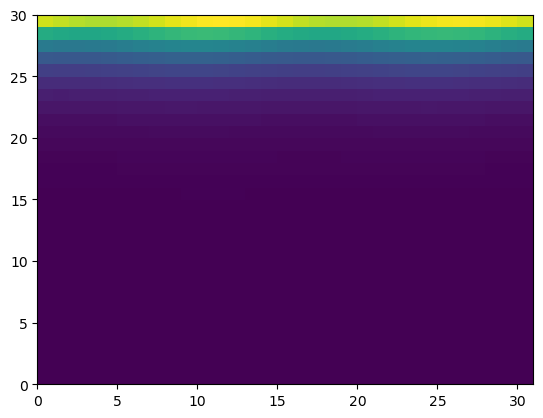

In [9]:
mag = np.sqrt(I[3,:,:,:]**2 + Q[3,:,:,:]**2)


plt.pcolor((mag[:,:,-1]))